4*2 이미지를 만드는 코드

In [62]:
def visualize(dfs, InfoQGAN = True):
    # get the epoch when df["p_value"].max() is reached
    # 
    for df in dfs:
        max_p_value = df["p_value"].max()
        epoch_max_p_value = df[df["p_value"] == max_p_value].index[0]
        print(f"max p-value: {max_p_value} at epoch {epoch_max_p_value}/{len(df)}")



Loaded box_1000_False_Oct01_15-32.csv
max p-value: 0.0396037453837146 at epoch 39/200
Loaded box_1000_False_Oct01_22-45.csv
max p-value: 0.0668900105874254 at epoch 78/200
Loaded box_1000_False_Oct03_00-57.csv
max p-value: 0.003607118888322 at epoch 156/200
Loaded box_1000_False_Oct03_18-42.csv
max p-value: 0.0568078457893511 at epoch 199/200
Loaded box_1000_True_Sep23_20-34.csv
max p-value: 0.3167078856694835 at epoch 42/1000
Loaded box_1000_True_Sep24_20-41.csv
max p-value: 0.5100404015542276 at epoch 57/1000
Loaded box_1000_True_Sep25_15-57.csv
max p-value: 0.5053636826000325 at epoch 188/1000
Loaded box_1000_True_Sep26_15-44.csv
max p-value: 0.3020056477259735 at epoch 121/200


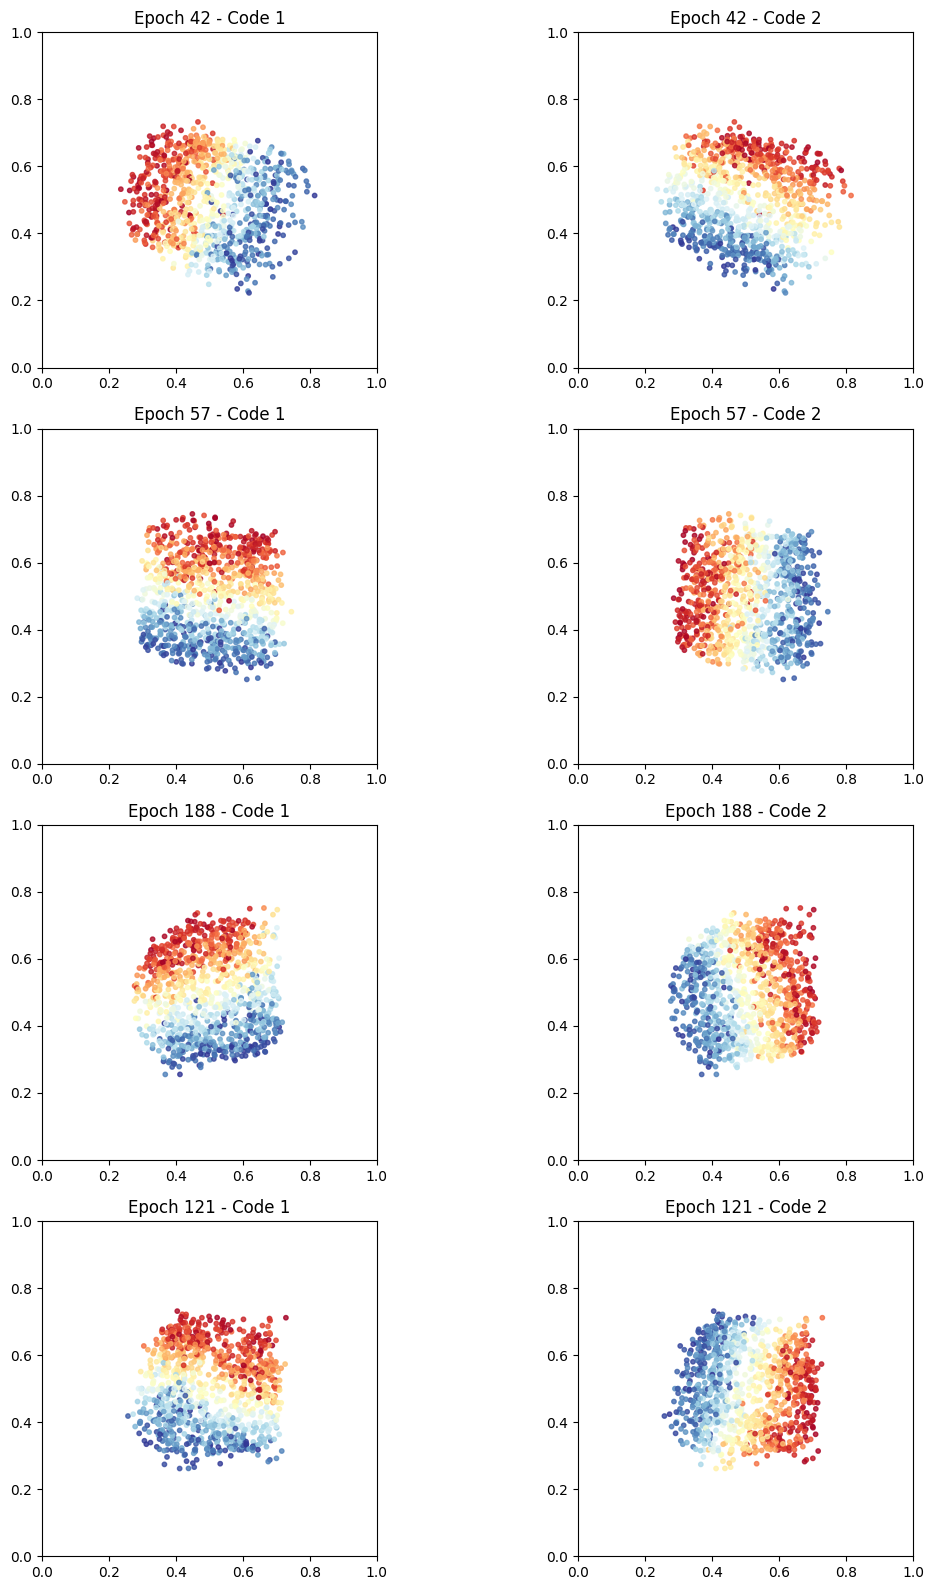

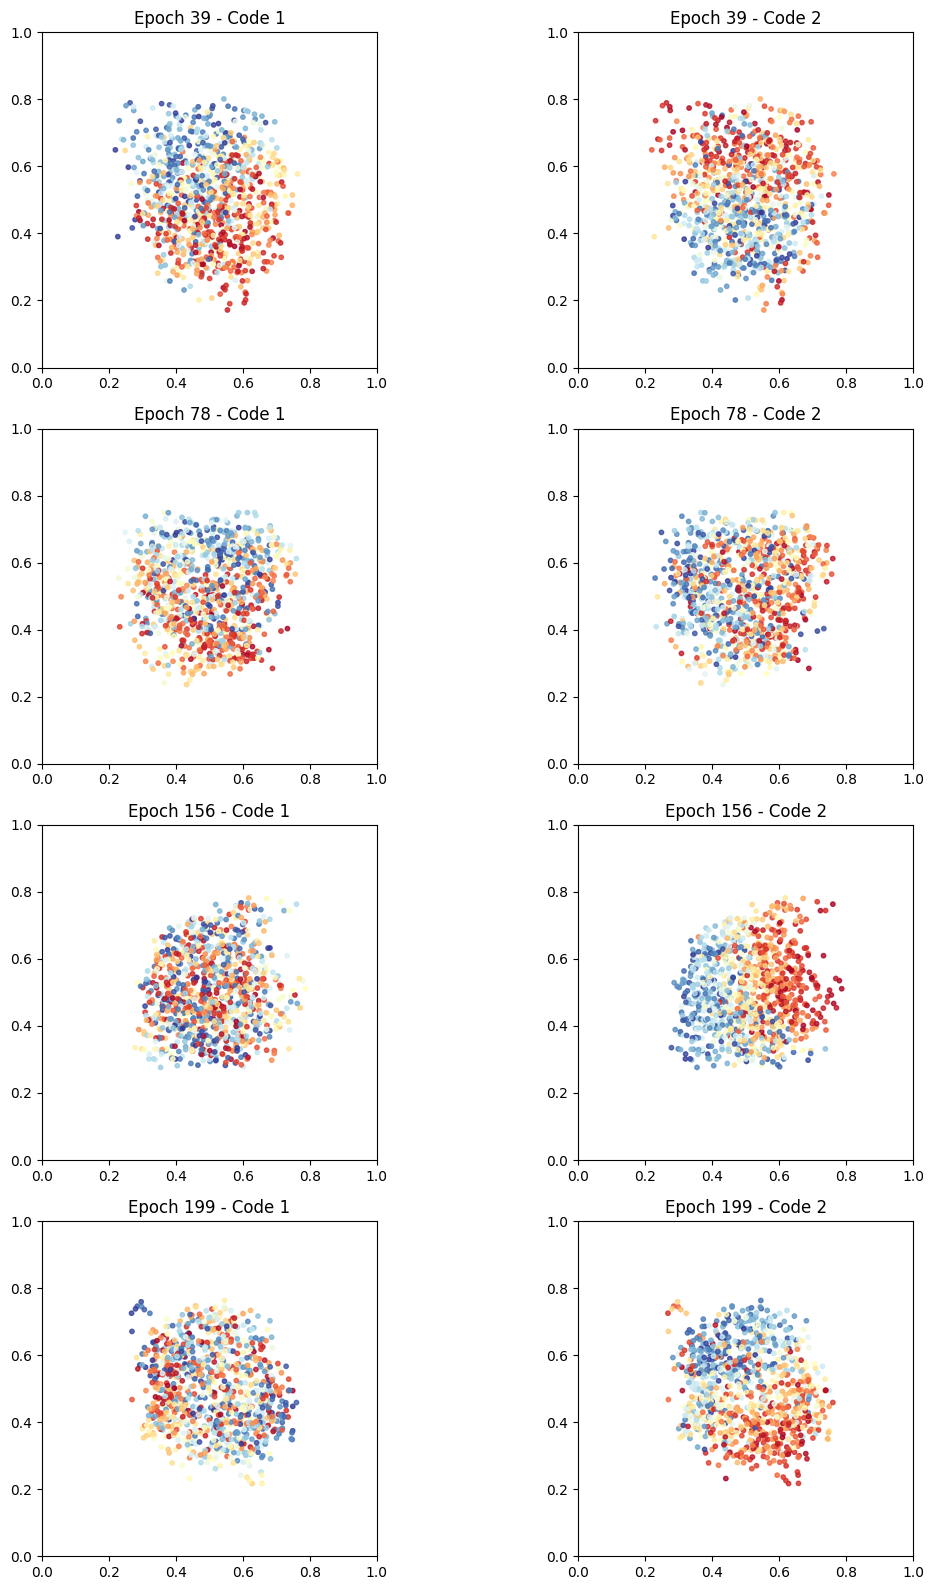

In [70]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

result_dir =  "../../결과/2D_square"
experiment_names = ["box_1000_False_Oct01_15-32", "box_1000_False_Oct01_22-45",
                    "box_1000_False_Oct03_00-57", "box_1000_False_Oct03_18-42",
                    "box_1000_True_Sep23_20-34", "box_1000_True_Sep24_20-41",
                    "box_1000_True_Sep25_15-57", "box_1000_True_Sep26_15-44"]

# True와 False 실험별로 인덱스를 관리합니다.
true_idx = 0
false_idx = 0

# True와 False에 대한 figure와 axes를 생성합니다.
fig_true, axes_true = plt.subplots(4, 2, figsize=(12, 16))
fig_false, axes_false = plt.subplots(4, 2, figsize=(12, 16))

for experiment_name in experiment_names:
    experiment_path = os.path.join(result_dir, f"{experiment_name}.csv")

    df = None
    if os.path.exists(experiment_path):
        # If the file exists, read it into a pandas DataFrame
        df = pd.read_csv(experiment_path)
        print(f"Loaded {experiment_name}.csv")
    else:
        # If the specific file doesn't exist, try to load 'scalars.csv'
        scalars_path = os.path.join(result_dir, "scalars.csv")
        if os.path.exists(scalars_path):
            df = pd.read_csv(scalars_path)
            print(f"{experiment_name}.csv not found. Loaded scalars.csv instead.")
        else:
            print(f"Neither {experiment_name}.csv nor scalars.csv found.")
            continue  # 파일이 없으면 다음 실험으로 넘어갑니다.
    
    max_p_value = df["p_value"].max()
    epoch_max_p_value = df[df["p_value"] == max_p_value]["epoch"].iloc[0]
    print(f"max p-value: {max_p_value} at epoch {epoch_max_p_value}/{len(df)}")

    # 데이터 파일 경로 설정
    outputs_path = os.path.join(result_dir, experiment_name, f"numpy/gen_outputs_epoch_{epoch_max_p_value}.txt")
    codes_path = os.path.join(result_dir, experiment_name, f"numpy/gen_codes_epoch_{epoch_max_p_value}.txt")
    
    # 데이터가 존재하는지 확인
    if not os.path.exists(outputs_path) or not os.path.exists(codes_path):
        print(f"Data files for epoch {epoch_max_p_value} not found in {outputs_path}.")
        continue  # 데이터가 없으면 다음 실험으로 넘어갑니다.

    # 데이터 로드
    outputs = np.loadtxt(outputs_path)
    codes = np.loadtxt(codes_path)

    # 첫 번째 코드와 두 번째 코드를 각각 사용하여 색상을 지정합니다.
    code1 = codes[:, 0]
    code2 = codes[:, 1]

    # 플롯할 축 선택
    if "True" in experiment_name:
        ax1 = axes_true[true_idx, 0]
        ax2 = axes_true[true_idx, 1]
        true_idx += 1
    else:
        ax1 = axes_false[false_idx, 0]
        ax2 = axes_false[false_idx, 1]
        false_idx += 1

    # 첫 번째 코드로 색상 지정하여 플롯 (RdYlBu cmap 및 alpha 값 적용)
    scatter1 = ax1.scatter(outputs[:, 0], outputs[:, 1], c=code1, cmap='RdYlBu', s=10, alpha=0.8)
    ax1.set_title(f'Epoch {epoch_max_p_value} - Code 1')
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.set_aspect('equal')

    # 두 번째 코드로 색상 지정하여 플롯 (RdYlBu cmap 및 alpha 값 적용)
    scatter2 = ax2.scatter(outputs[:, 0], outputs[:, 1], c=code2, cmap='RdYlBu', s=10, alpha=0.8)
    ax2.set_title(f'Epoch {epoch_max_p_value} - Code 2')
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.set_aspect('equal')

# 레이아웃 조정 및 이미지 저장
fig_true.tight_layout()
fig_false.tight_layout()

fig_true.savefig(os.path.join(result_dir, "True_experiments.png"))
fig_false.savefig(os.path.join(result_dir, "False_experiments.png"))

plt.show()


In [58]:
df_true[0]["p_value"].max()

0.3167078856694835

0        1.184452581952652e-50
1                      p_value
2       1.4663389481233612e-39
3                      p_value
4         9.89386754857458e-17
                 ...          
1994     2.953481875553518e-07
1995                   p_value
1996     3.894930631418896e-07
1997                   p_value
1998      9.22357422886448e-08
Name: p_value, Length: 1999, dtype: object

In [46]:
import os
import csv

def remove_duplicate_headers(file_path):
    # 데이터를 저장할 리스트
    rows = []

    # 중복된 헤더를 제거하기 위해 첫 번째 줄을 헤더로 간주
    with open(file_path, 'r', encoding='utf-8') as infile:
        csvreader = csv.reader(infile)
        header = next(csvreader)  # 첫 번째 헤더 읽기
        rows.append(header)       # 헤더를 rows에 추가

        # 중복되지 않은 나머지 데이터를 rows에 추가
        for row in csvreader:
            if row == header:
                continue  # 중복된 헤더 건너뛰기
            rows.append(row)

    # 동일한 파일 경로에 새로 작성
    with open(file_path, 'w', newline='', encoding='utf-8') as outfile:
        csvwriter = csv.writer(outfile)
        csvwriter.writerows(rows)  # 모든 데이터를 다시 파일에 쓰기

result_dir = "../../결과/2D_square"
experiment_names = [
    "box_1000_False_Oct01_15-32", "box_1000_False_Oct01_22-45",
    "box_1000_False_Oct03_00-57", "box_1000_False_Oct03_18-42",
    "box_1000_True_Sep23_20-34", "box_1000_True_Sep24_20-41",
    "box_1000_True_Sep25_15-57", "box_1000_True_Sep26_15-44"
]

# 각 실험 파일에서 중복 헤더 제거
for experiment_name in experiment_names:
    experiment_path = os.path.join(result_dir, f"{experiment_name}.csv")
    remove_duplicate_headers(experiment_path)
